In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import os
import seaborn as sns

from tp7.tp7 import Tape7
from srfs.srfs import SRFS
import scipy.integrate as integrate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.tree import export_text, plot_tree

import warnings
warnings.filterwarnings('ignore')

In [2]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']
# tot_wvln = srf.srf_vals['wavelength_um']
# sw_srf = srf.srf_vals['sw_srf']
# lw_srf = srf.srf_vals['lw_srf']

viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

In [3]:
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :] * 1e6, 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [4]:
def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 1:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [5]:
y_lim_map = {
    "Snow": [[1.75e-6, 4], [1e-5, 100]],
    "Cloudy Ocean": [[2.25e-6, 5], [1e-5, 100]],
    "Land": [[600, 3], [10, 50]],
    "Clear Ocean": [[7e-7, 3], [1.75e-5, 100]],
    "Deep Convective Cloud": [[500, 3], [2.5, 80]]
}

def plot_sza(sza_dict: dict):
    fig, axes = plt.subplots(5, 1, figsize=(18, 50))

    for i, (key, tp7) in enumerate(sza_dict.items()):

        wavelength = tp7.rads[0, 0, :]

        print(key)
        ax_sw = axes[i]
        shortwave = tp7.rads[-1, 1, :]
        interp_shortwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=sw_srf)
        shortwave_filt = interp_shortwave_filt * shortwave

        ax_sw.plot(wavelength, shortwave_filt, 'r-', label='Filtered')
        ax_sw.plot(wavelength, shortwave, 'b-', label='Unfiltered')
        # ax_sw.set_xlim(0, y_lim_map[key][0][1])
        # ax_sw.set_ylim(0, y_lim_map[key][0][0])
        ax_sw.set_xlim(0, y_lim_map["Land"][0][1])
        ax_sw.set_ylim(0, y_lim_map["Land"][0][0])

        ax_sw.legend(prop={"size": 10})
        ax_sw.set_title(f'Shortwave: {key}')
        ax_sw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        ax_sw.set_xlabel('Wavelength µm')
        ax_sw.grid(True)


        # ax_lw = axes[i, 1]
        # longwave = tp7.rads[-1, 2, :]
        # longwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=lw_srf)
        # longwave_filt = longwave_filt * shortwave
        # ax_lw.plot(wavelength, longwave, longwave_filt, 'b-', label='Longwave')
        # ax_lw.set_xlim(5, y_lim_map[key][1][1])
        # ax_lw.set_ylim(0, y_lim_map[key][1][0])
        #
        # ax_lw.legend(prop={"size": 10})
        # ax_lw.set_title(f'Longwave: {key}')
        # ax_lw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        # ax_lw.set_xlabel('Wavelength µm')
        # ax_lw.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.show()

In [6]:
def viirs_band_integration(tp7_data: Tape7, rad_indxs: dict):
    for idx, run in enumerate(tp7_data.rads):
        for band, rng in rad_indxs.items():
            y_vals = run[1][rng[0]: rng[1] + 1]
            x_vals = run[0][rng[0]: rng[1] + 1]
            integrated = integrate.simpson(y=y_vals, x=x_vals)
            tp7_data.describer_df.loc[idx, band] = integrated

In [7]:
a00_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

a41_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}

a60_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a60_files]
titles = [file.title for file in a60_data]
a60 = {title: file for title, file in zip(titles, a60_data)}

a75_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a75_files]
titles = [file.title for file in a75_data]
a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}


In [8]:
snow_data = [a00["Snow"], a41["Snow"], a60["Snow"], a75["Snow"], a85["Snow"]]
dc_data = [a00["Deep Convective Cloud"], a41["Deep Convective Cloud"], a60["Deep Convective Cloud"],
           a75["Deep Convective Cloud"], a85["Deep Convective Cloud"]]
land_data = [a00["Land"], a41["Land"], a60["Land"], a75["Land"], a85["Land"]]
clear_data = [a00["Clear Ocean"], a41["Clear Ocean"], a60["Clear Ocean"], a75["Clear Ocean"], a85["Clear Ocean"]]
cloudy_data = [a00["Cloudy Ocean"], a41["Cloudy Ocean"], a60["Cloudy Ocean"], a75["Cloudy Ocean"], a85["Cloudy Ocean"]]
[viirs_band_integration(data, viirs_rads_indxs) for data in snow_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in dc_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in land_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in clear_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in cloudy_data]

[None, None, None, None, None]

In [9]:
snow_dfs = [file.describer_df for file in snow_data]
snow_dataset = pd.concat(snow_dfs, axis=0)
land_dfs = [file.describer_df for file in land_data]
dc_dfs = [file.describer_df for file in dc_data]
cloud_dfs = [file.describer_df for file in cloudy_data]
clear_dfs = [file.describer_df for file in clear_data]
land_dataset = pd.concat(land_dfs, axis=0)
dc_dataset = pd.concat(dc_dfs, axis=0)
cloud_dataset = pd.concat(cloud_dfs, axis=0)
clear_dataset = pd.concat(clear_dfs, axis=0)
all_dataset = pd.concat([snow_dataset, land_dataset, dc_dataset, cloud_dataset, clear_dataset])

In [10]:
def run_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    if rf:
        base_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    else:
        base_model = LinearRegression()
    regression_model = MultiOutputRegressor(base_model)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    rmse = root_mean_squared_error(y_test, y_pred, multioutput='raw_values')
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse[0] / tg_range_sw)) * 100

    tg_range_lw = max(y_test["Longwave Unfiltered Rads (Integrated)"]) - min(y_test["Longwave Unfiltered Rads (Integrated)"])
    ret["Longwave MSPE"] = (1.0 - (rmse[1] / tg_range_lw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores
    ret["Model"] = regression_model
    ret["Predictions"] = y_pred
    ret["Y_True"] = y_test

    return ret


In [11]:
def run_shortwave_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)"]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    regression_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    # ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores

    return [ret, y_pred]

In [12]:
def estimator_testing(scene: str, dataset: pd.DataFrame):
    res = {}
    N = [10, 25, 50, 100, 125, 150, 200]
    tests = [run_regression_model(dataset, neurons=n) for n in N]
    for i in range(len(N)):
        del tests[i]["Model"]
        del tests[i]["Predictions"]
        del tests[i]["Y_True"]
        res[f"{scene}_{N[i]}"] = tests[i]

    return res

In [13]:
def plot_ml_est(results_dict):
    """
    Plots different accuracy metrics against the number of estimators.

    :param results_dict: Dictionary with the format:
                         {
                             num_estimators_1: {
                                 "Single MSE": value,
                                 "RMSE": value,
                                 "MAE": value,
                                 "MAEP": value,
                                 "Shortwave MSPE": value,
                                 "Longwave MSPE": value,
                                 "CV RMSPE": value
                             },
                             num_estimators_2: {...},
                             ...
                         }
    """
    # Extracting number of estimators and metrics
    num_estimators = results_dict.keys()
    # print(num_estimators)
    metrics = ["Single MSE", "RMSE", "MAE", "MAEP", "Shortwave MSPE", "Longwave MSPE", "CV RMSE"]

    # Creating a figure for each metric
    for metric in metrics:
        metric_values = [results_dict[est][metric] for est in num_estimators]

        plt.figure(figsize=(8, 5))
        plt.plot(num_estimators, metric_values, marker='o', linestyle='-')
        plt.xlabel("Number of Estimators")
        plt.ylabel(metric)
        plt.title(f"{metric} vs. Number of Estimators")
        plt.grid(True)
        plt.show()

In [17]:
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object')

# Plan from Vikas

check shortwave and longwave plots for all

put together block diagram of the algorithm

plot by the predictions/ground truth and then do it for each scene do a scatter plot

focal loss or weighted mean squared error

chart accuracy vs number of estimators

correlation for pred v ground truth

pred - ground truth / ground truth

stratified by SZA

add noise purposely 1 sigma noise

DOUBLE CHECK THE LONGWAVE GRAPHS LIKE YOU DID WITH THE SHORT + INTEGRATED

do the bands too!

set numpy random state 42

do a plot of different estimators for each of the scenes

plot estimators and accuracy

Snow
Land
Clear Ocean
Cloudy Ocean
Deep Convective Cloud


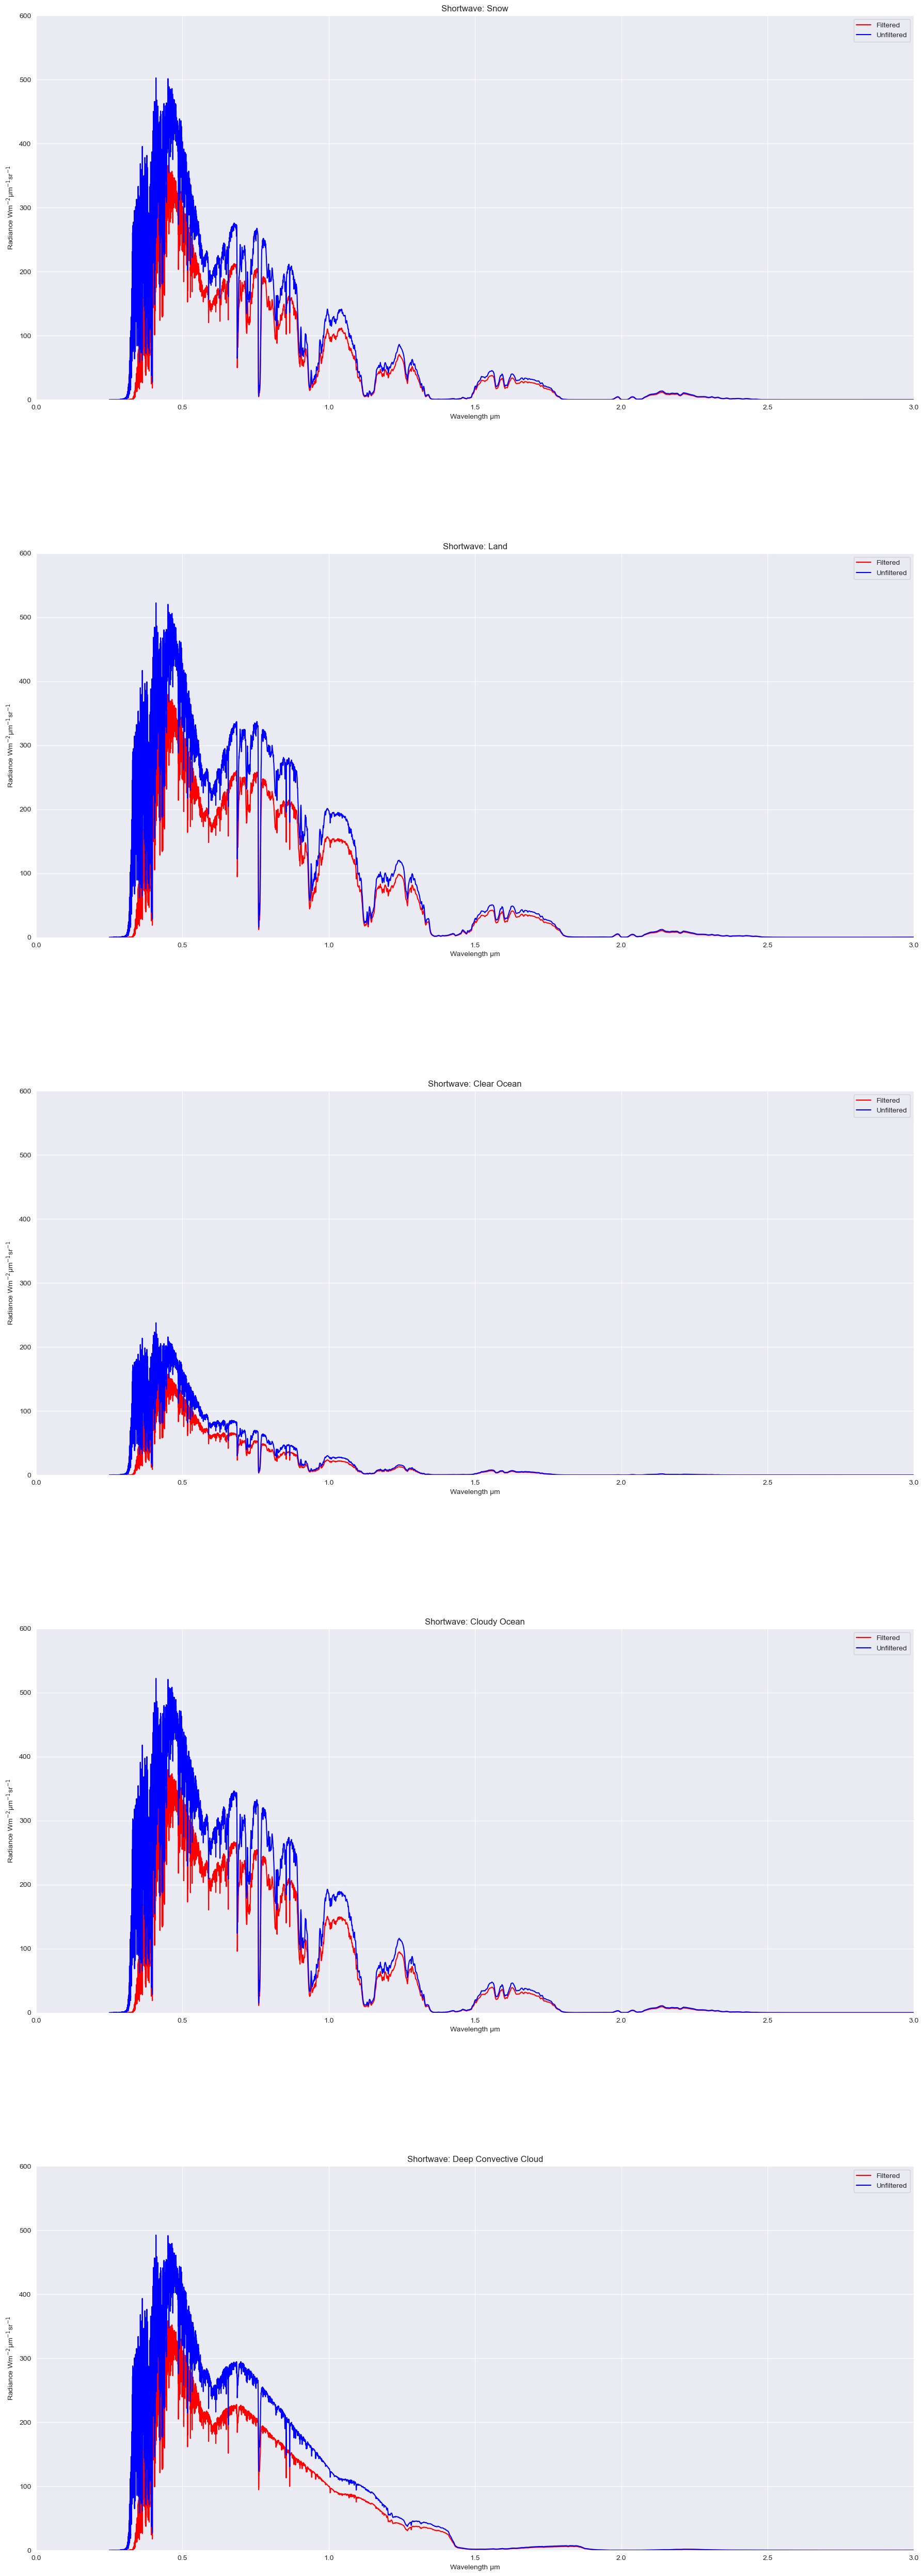

In [85]:
plot_sza(a00)

In [15]:
# plot_sza(a41)

In [16]:
# plot_sza(a60)

In [17]:
# plot_sza(a75)

In [18]:
# plot_sza(a85)

In [14]:
all_res = run_shortwave_regression_model(all_dataset, 100)

Index(['SZA', 'VZA', 'RAZ', 'Cloud', 'Shortwave Filtered Rads (Integrated)',
       'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9',
       'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object') Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


In [15]:
all_res

{'Single MSE': 1.4209858823855115,
 'RMSE': 1.1920511240653697,
 'MAE': 0.3186874615866022,
 'Shortwave MSPE': 99.79611265203997,
 'CV RMSE': array([-7.15844268, -2.76372374, -0.63921087, -2.63548524, -3.17413055])}

In [36]:
np.sqrt(all_res["Single MSE"])

1.1920511240653697

In [14]:
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object')

In [86]:
all_dataset

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,M12,M13,M14,M15,I5,M16,Scaled Shortwave Filtered,Scaled Shortwave Unfiltered,Scaled Longwave Filtered,Scaled Longwave Unfiltered
0,Snow,0.000,0.000,0.0,0,0,307.528673,64.630148,223.024942,42.028651,...,0.004348,0.001302,0.000088,0.000138,0.000294,0.000190,0.461624,0.500871,0.492051,0.477688
1,Snow,0.000,0.000,0.0,1,1,308.989576,61.707542,224.234444,40.175852,...,0.013530,0.005802,0.000327,0.000176,0.000381,0.000226,0.464154,0.503278,0.453498,0.439632
2,Snow,0.000,0.000,0.0,1,2,307.570444,65.121000,222.758504,42.332800,...,0.003081,0.000960,0.000084,0.000111,0.000276,0.000193,0.461066,0.500940,0.498380,0.484079
3,Snow,0.000,0.000,0.0,1,3,367.808738,53.795463,271.419300,35.158965,...,0.347688,0.160067,0.012621,0.007502,0.010138,0.003258,0.562855,0.600195,0.349106,0.336606
4,Snow,0.000,0.000,0.0,1,4,323.988001,63.367576,236.683397,41.264825,...,0.377263,0.147548,0.011686,0.006478,0.008392,0.002541,0.490194,0.527991,0.476157,0.461247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,83.845,89.947,172.5,0,142,55.161028,68.826211,38.615647,44.514829,...,0.002860,0.000531,0.000014,0.000010,0.000013,0.000005,0.075878,0.085044,0.543784,0.532326
143,Clear Ocean,83.845,89.947,172.5,0,143,58.683832,68.796818,41.349000,44.500770,...,0.004841,0.000933,0.000018,0.000013,0.000016,0.000006,0.081595,0.090849,0.543491,0.531943
144,Clear Ocean,83.845,89.947,172.5,0,144,62.944481,68.745825,44.649744,44.474058,...,0.008280,0.001732,0.000027,0.000019,0.000023,0.000008,0.088500,0.097869,0.542935,0.531279
145,Clear Ocean,83.845,89.947,172.5,0,145,68.463058,68.719250,48.909934,44.461081,...,0.013350,0.003030,0.000036,0.000023,0.000027,0.000009,0.097411,0.106962,0.542665,0.530933


In [17]:
min(all_dataset["Shortwave Filtered Rads (Integrated)"]), max(all_dataset["Shortwave Filtered Rads (Integrated)"])

(2.341706313336201, 480.40057188125786)

In [18]:
min(all_dataset["Shortwave Unfiltered Rads (Integrated)"]), max(all_dataset["Shortwave Unfiltered Rads (Integrated)"])

(3.5472382110609804, 610.4526726464998)

In [15]:
min_shortwave = min(all_dataset["Shortwave Filtered Rads (Integrated)"])
max_shortwave = max(all_dataset["Shortwave Filtered Rads (Integrated)"])
scaler = MinMaxScaler(feature_range=(min_shortwave, max_shortwave))
all_dataset["Scaled Shortwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Shortwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Shortwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Shortwave Unfiltered Rads (Integrated)']])
all_dataset["Scaled Longwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Longwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Longwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Longwave Unfiltered Rads (Integrated)']])
min(all_dataset["Scaled Shortwave Unfiltered"]), max(all_dataset["Scaled Shortwave Unfiltered"])

(0.0, 1.0)

In [20]:
min(all_dataset["Scaled Shortwave Filtered"]), max(all_dataset["Scaled Shortwave Filtered"])

(0.0, 1.0)

In [21]:
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered'],
      dtype='object')

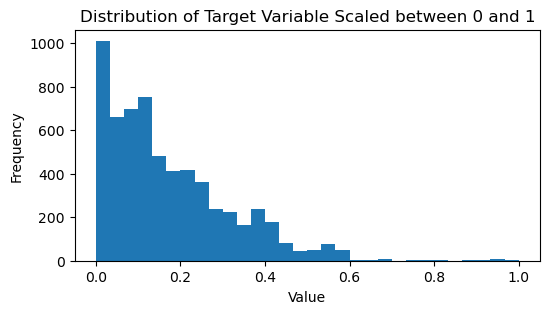

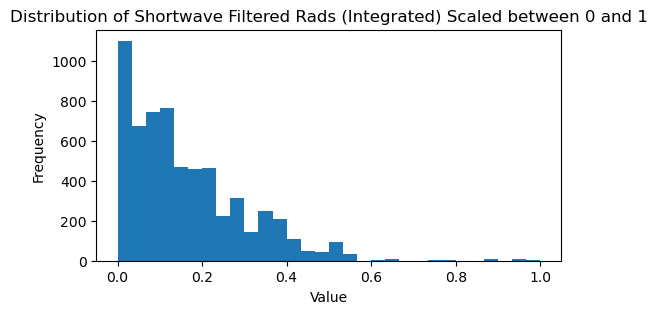

In [17]:
plt.figure(figsize=(6, 3))
plt.hist(all_dataset["Scaled Shortwave Unfiltered"], bins=30)
plt.title('Distribution of Target Variable Scaled between 0 and 1')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(6, 3))
plt.hist(all_dataset["Scaled Shortwave Filtered"], bins=30)
plt.title(f'Distribution of Shortwave Filtered Rads (Integrated) Scaled between 0 and 1')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

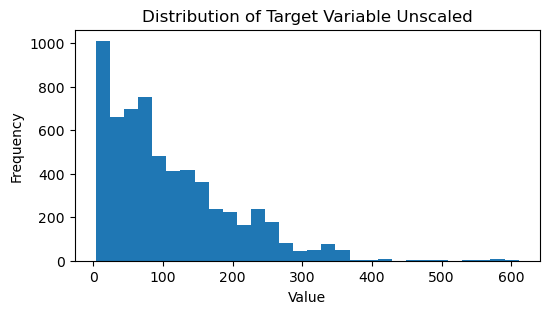

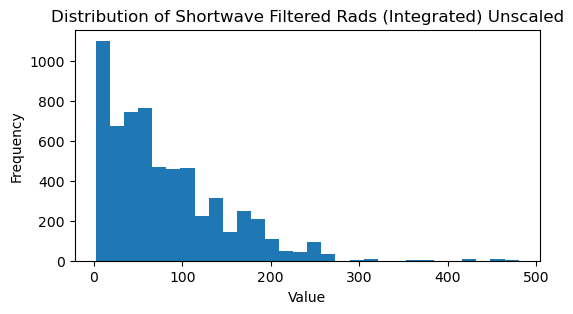

In [18]:
plt.figure(figsize=(6, 3))
plt.hist(all_dataset["Shortwave Unfiltered Rads (Integrated)"], bins=30)
plt.title('Distribution of Target Variable Unscaled')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(6, 3))
plt.hist(all_dataset["Shortwave Filtered Rads (Integrated)"], bins=30)
plt.title(f'Distribution of Shortwave Filtered Rads (Integrated) Unscaled')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [27]:
def add_noise_to_features(X: np.ndarray, noise_level: float, seed: int = 42):
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    return X + noise


In [28]:
def run_shortwave_regression_model_scaled(dataset: pd.DataFrame, scaled: bool, rf: bool, v: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None
    if scaled:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered',
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1', "Cloud",]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16',]).reset_index(drop=True)

    else:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",  "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Filtered', 'Scaled Shortwave Unfiltered',
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1', "Cloud",]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)
    # X_train, X_test = X_train.to_numpy(), X_test.to_numpy()
    # y_train, y_test = list(y_train["Shortwave Unfiltered Rads (Integrated)"]), list(y_test["Shortwave Unfiltered Rads (Integrated)"])

    # print(X_train.to_numpy())

    if rf:
        regression_model = RandomForestRegressor(n_estimators=neurons, random_state=42, max_depth=tree_depth)
    else:
        regression_model = LinearRegression()
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]

In [29]:
def run_MLP(dataset: pd.DataFrame, scaled: bool, v: bool, noised: bool, noise_level: float = 0.01, neurons: tuple = (8, 4), max_iter: int = 500):

    ret = {}
    X, y = None, None
    if scaled:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered',
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    else:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",  "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Filtered', 'Scaled Shortwave Unfiltered',
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)


    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    MLP = MLPRegressor(
        # hidden_layer_sizes=(32, 16, 8), # best for scaled (8, 4)
        hidden_layer_sizes=neurons,
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=max_iter,
        random_state=42
    )

    MLP.fit(X_train, y_train)

    # Evaluate
    train_accuracy = MLP.score(X_train, y_train)
    test_accuracy = MLP.score(X_test, y_test)

    y_pred = MLP.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv_scores = cross_val_score(MLP, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(MLP, X, y, cv=5, scoring="r2")

    ret["Mean_Absolute_Error"] = mae
    ret["Train_Accuracy"] = train_accuracy
    ret["Test_Accuracy"] = test_accuracy
    ret["Mean_Squared_Error"] = mse
    ret["R_Squared"] = r2
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["Model"] = MLP

    return [ret, y_pred, y_test]


In [30]:
def compare_MLP_neurons(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8))):
    # unscaled data
    mlp_neuron_results = [run_MLP(dataset=dataset, scaled=False, v=False, neurons=n, noised=False) for n in neurons]
    return dict(zip(neurons, mlp_neuron_results))

def comapare_MLP_max_iter(dataset: pd.DataFrame, max_iter: list = (5, 10, 50, 100, 250, 500)):
    mlp_max_iter_results = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, max_iter=mx) for mx in max_iter]
    return dict(zip(max_iter, mlp_max_iter_results))

def compare_tree_depth(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10)):
    tree_depth_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False,  noised=False, neurons=100, tree_depth=td) for td in tree_depth]
    return dict(zip(tree_depth, tree_depth_res))

def compare_tree_estimators(dataset: pd.DataFrame, estimators: list = (1,5,10,25,50,100)):
    tree_est_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False,  noised=False, neurons=est, tree_depth=10) for est in estimators]
    return dict(zip(estimators, tree_est_res))

def compare_tree_td_est(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10), estimators: list = (1,5,10,25,50,100)):
    vars = [(td, est) for td in tree_depth for est in estimators]
    res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False,  noised=False, neurons=est, tree_depth=td) for td, est in vars]
    return dict(zip(vars, res))

def compare_mlp_neurons_iters(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8)), max_iter: list = (5, 10, 50, 100, 250, 500)):
    vars = [(n, mx) for n in neurons for mx in max_iter]
    res = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, neurons=n, max_iter=mx) for n, mx in vars]
    return dict(zip(vars, res))

def compare_noise_mlp(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_MLP(dataset=dataset, scaled=False, v=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

def compare_noise_tree(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_shortwave_regression_model_scaled(dataset=dataset, scaled=False, v=False, rf=True, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))


In [19]:
mlp_neuron_comparison = compare_MLP_neurons(all_dataset)
mlp_neuron_comparison

{2: [{'Mean_Absolute_Error': 1.2343687998135853,
   'Train_Accuracy': 0.9995102773170298,
   'Test_Accuracy': 0.9995049211614154,
   'Mean_Squared_Error': 4.083748474734383,
   'R_Squared': 0.9995049211614154,
   'Cross_Validated_Root_Mean_Squared_Error': array([2.84719555, 2.78983213, 0.88872214, 2.91879486, 1.68933922]),
   'Cross_Validated_R_Squared': array([0.99874523, 0.99918573, 0.99972442, 0.9988794 , 0.99944855]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=2, learning_rate='adaptive',
                max_iter=500, random_state=42)},
  array([ 51.10725826,  88.42800497, 344.56185357, ...,  21.45295216,
          17.46859718, 127.33420025]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 (2,
  2): [{'Mean_Absolute_Error': 99.67836945961535,
   'Train_Accuracy': -1.1813534354010131,
   'Test_Accuracy': -1.1957463987987205,
   'Mean_Squared_Error': 

In [20]:
mlp_max_iter_comparison = comapare_MLP_max_iter(all_dataset)
mlp_max_iter_comparison

{5: [{'Mean_Absolute_Error': 51.19328611778193,
   'Train_Accuracy': 0.3555407622134106,
   'Test_Accuracy': 0.351392733305693,
   'Mean_Squared_Error': 5350.155833033391,
   'R_Squared': 0.351392733305693,
   'Cross_Validated_Root_Mean_Squared_Error': array([103.6990759 ,  88.32518562,  49.11241776,  57.03171028,
           46.81352781]),
   'Cross_Validated_R_Squared': array([-0.66448658,  0.18382756,  0.15840105,  0.57216363,  0.57653727]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=(8, 4), learning_rate='adaptive',
                max_iter=5, random_state=42)},
  array([ 39.8459039 ,  45.19593575, 144.04774739, ...,  45.41232115,
          43.366823  ,  68.78624318]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 10: [{'Mean_Absolute_Error': 21.791935926896027,
   'Train_Accuracy': 0.9040686622575959,
   'Test_Accuracy': 0.9060599659400626,
   'Mea

In [21]:
tree_depth_comparison = compare_tree_depth(all_dataset)
tree_depth_comparison

{1: [{'Mean_Absolute_Percentage_Error': 87.77086148492083,
   'Root_Mean_Squared_Error': 50.18916174171528,
   'Mean_Absolute_Error': 38.70876657359015,
   'Accuracy': 12.229138515079171,
   'Cross_Validated_Root_Mean_Squared_Error': array([56.07426272, 54.5406724 , 42.8591251 , 55.76880381, 51.89037657]),
   'Cross_Validated_R_Squared': array([0.51330412, 0.68878983, 0.35907212, 0.5909018 , 0.47970926]),
   'R_Squared': 0.694623746612053,
   'Model': RandomForestRegressor(max_depth=1, random_state=42)},
  array([ 62.20288204,  62.20288204, 221.91477505, ...,  62.20288204,
          62.20288204,  62.20288204]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 2: [{'Mean_Absolute_Percentage_Error': 38.89356635694488,
   'Root_Mean_Squared_Error': 25.585116047713157,
   'Mean_Absolute_Error': 18.941663303200496,
   'Accuracy': 61.10643364305512,
   'Cross_Validated_Root_

In [22]:
"""
For the below est comparison use different tree depths as well just to show how to build up the model
"""

'\nFor the below est comparison use different tree depths as well just to show how to build up the model\n'

In [23]:
tree_est_comparison = compare_tree_estimators(all_dataset)
tree_est_comparison

{1: [{'Mean_Absolute_Percentage_Error': 1.184834214533698,
   'Root_Mean_Squared_Error': 1.459707992990503,
   'Mean_Absolute_Error': 0.7630121413544235,
   'Accuracy': 98.8151657854663,
   'Cross_Validated_Root_Mean_Squared_Error': array([6.14324786, 3.22278964, 1.37667845, 4.42932888, 4.4429267 ]),
   'Cross_Validated_R_Squared': array([0.99415847, 0.99891338, 0.99933872, 0.9974194 , 0.99618574]),
   'R_Squared': 0.9997416863533801,
   'Model': RandomForestRegressor(max_depth=10, n_estimators=1, random_state=42)},
  array([ 50.00373934,  86.54566624, 348.79008625, ...,  21.15341836,
          17.18843905, 126.36910024]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 5: [{'Mean_Absolute_Percentage_Error': 0.8307978607266502,
   'Root_Mean_Squared_Error': 0.8950550988418912,
   'Mean_Absolute_Error': 0.5602673265823885,
   'Accuracy': 99.16920213927335,
   'Cross_Va

In [24]:
all_td_est_comparison = compare_tree_td_est(all_dataset)
all_td_est_comparison

{(1,
  1): [{'Mean_Absolute_Percentage_Error': 87.55819349156478,
   'Root_Mean_Squared_Error': 51.316340667882045,
   'Mean_Absolute_Error': 39.6980676654533,
   'Accuracy': 12.44180650843522,
   'Cross_Validated_Root_Mean_Squared_Error': array([57.84987848, 54.41236786, 46.31540816, 55.57256275, 51.9943487 ]),
   'Cross_Validated_R_Squared': array([0.48199324, 0.69025232, 0.25153146, 0.59377583, 0.47762218]),
   'R_Squared': 0.6807530643348949,
   'Model': RandomForestRegressor(max_depth=1, n_estimators=1, random_state=42)}, array([ 61.50642826,  61.50642826, 222.81567133, ...,  61.50642826,
          61.50642826,  61.50642826]), array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 (1,
  5): [{'Mean_Absolute_Percentage_Error': 89.06365504912131,
   'Root_Mean_Squared_Error': 50.06741078206178,
   'Mean_Absolute_Error': 38.81784465895393,
   'Accuracy': 10.936344950878691,


In [25]:
all_mlp_neurons_iters_comparison = compare_mlp_neurons_iters(all_dataset)
all_mlp_neurons_iters_comparison

{(2,
  5): [{'Mean_Absolute_Error': 107.9245584224196,
   'Train_Accuracy': -1.1793629776592365,
   'Test_Accuracy': -1.1645072338434983,
   'Mean_Squared_Error': 17854.33435214457,
   'R_Squared': -1.1645072338434983,
   'Cross_Validated_Root_Mean_Squared_Error': array([177.97482037, 145.85344415, 113.55987316, 112.50267245,
           89.4796536 ]),
   'Cross_Validated_R_Squared': array([-3.90283924, -1.22559524, -3.49958391, -0.66483268, -0.54710944]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=2, learning_rate='adaptive',
                max_iter=5, random_state=42)}, array([ -0.78036452,  -0.78036452,  49.70549077, ..., -29.12987186,
          -3.57958008,  -0.78036452]), array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 (2,
  10): [{'Mean_Absolute_Error': 62.91471771966248,
   'Train_Accuracy': 0.13067318854768717,
   'Test_Accuracy': 0.128731388314427

In [31]:
all_mlp_noise_comparison = compare_noise_mlp(all_dataset)
all_mlp_noise_comparison

{0: [{'Mean_Absolute_Error': 1.4142247221960287,
   'Train_Accuracy': 0.9993642017730769,
   'Test_Accuracy': 0.9993469587453174,
   'Mean_Squared_Error': 5.386730395048138,
   'R_Squared': 0.9993469587453174,
   'Cross_Validated_Root_Mean_Squared_Error': array([2.9224335 , 3.28397799, 0.74450014, 3.26972216, 2.01928419]),
   'Cross_Validated_R_Squared': array([0.99867804, 0.99887173, 0.9998066 , 0.99859374, 0.99921211]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=(8, 4), learning_rate='adaptive',
                max_iter=500, random_state=42)},
  array([ 50.28241833,  87.826602  , 343.35429608, ...,  21.17514442,
          16.47522386, 126.40504149]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 0.01: [{'Mean_Absolute_Error': 1.4133711515519038,
   'Train_Accuracy': 0.9993643564166825,
   'Test_Accuracy': 0.9993471964176103,
   'Mean_Squared_Error': 

In [32]:
all_tree_noise_comparison = compare_noise_tree(all_dataset)
all_tree_noise_comparison

{0: [{'Mean_Absolute_Percentage_Error': 0.7347429658625121,
   'Root_Mean_Squared_Error': 0.8544535030709338,
   'Mean_Absolute_Error': 0.5072555753714032,
   'Accuracy': 99.26525703413749,
   'Cross_Validated_Root_Mean_Squared_Error': array([5.77987368, 2.15911602, 0.93868794, 1.78663513, 3.0470108 ]),
   'Cross_Validated_R_Squared': array([0.99482909, 0.99951229, 0.99969256, 0.99958013, 0.99820601]),
   'R_Squared': 0.9999114900190178,
   'Model': RandomForestRegressor(max_depth=10, random_state=42)},
  array([ 50.2935176 ,  86.5743519 , 348.77291356, ...,  21.16437618,
          16.99820388, 127.8343468 ]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 0.01: [{'Mean_Absolute_Percentage_Error': 0.7639738641342328,
   'Root_Mean_Squared_Error': 0.9797120393216323,
   'Mean_Absolute_Error': 0.5423862365249252,
   'Accuracy': 99.23602613586577,
   'Cross_Validated_Ro

In [33]:
all_unscaled_res_linear_regression = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=False, v=True,  noised=False, neurons=100,)
all_unscaled_res_linear_regression[0]

Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)'], dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


{'Mean_Absolute_Percentage_Error': 1.7907052787381477,
 'Root_Mean_Squared_Error': 2.3225999346276565,
 'Mean_Absolute_Error': 1.3071459600243585,
 'Accuracy': 98.20929472126186,
 'Cross_Validated_Root_Mean_Squared_Error': array([3.0656275 , 3.35629646, 0.95115663, 3.32088313, 1.93832164]),
 'Cross_Validated_R_Squared': array([0.99854531, 0.99882149, 0.99968433, 0.99854939, 0.99927402]),
 'R_Squared': 0.9993460204062952,
 'Model': LinearRegression()}

In [34]:
all_unscaled_res_random_forest = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=True, v=True, noised=False, neurons=100, tree_depth=10)
all_unscaled_res_random_forest[0]

Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)'], dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


{'Mean_Absolute_Percentage_Error': 0.7347429658625121,
 'Root_Mean_Squared_Error': 0.8544535030709338,
 'Mean_Absolute_Error': 0.5072555753714032,
 'Accuracy': 99.26525703413749,
 'Cross_Validated_Root_Mean_Squared_Error': array([5.77987368, 2.15911602, 0.93868794, 1.78663513, 3.0470108 ]),
 'Cross_Validated_R_Squared': array([0.99482909, 0.99951229, 0.99969256, 0.99958013, 0.99820601]),
 'R_Squared': 0.9999114900190178,
 'Model': RandomForestRegressor(max_depth=10, random_state=42)}

In [35]:
all_unscaled_mlp = run_MLP(all_dataset, False, True, False,(2))
all_unscaled_mlp[0]

Input Features Index(['SZA', 'VZA', 'RAZ', 'Cloud', 'Shortwave Filtered Rads (Integrated)'], dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


{'Mean_Absolute_Error': 1.4142247221960287,
 'Train_Accuracy': 0.9993642017730769,
 'Test_Accuracy': 0.9993469587453174,
 'Mean_Squared_Error': 5.386730395048138,
 'R_Squared': 0.9993469587453174,
 'Cross_Validated_Root_Mean_Squared_Error': array([2.9224335 , 3.28397799, 0.74450014, 3.26972216, 2.01928419]),
 'Cross_Validated_R_Squared': array([0.99867804, 0.99887173, 0.9998066 , 0.99859374, 0.99921211]),
 'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=(8, 4), learning_rate='adaptive',
              max_iter=500, random_state=42)}

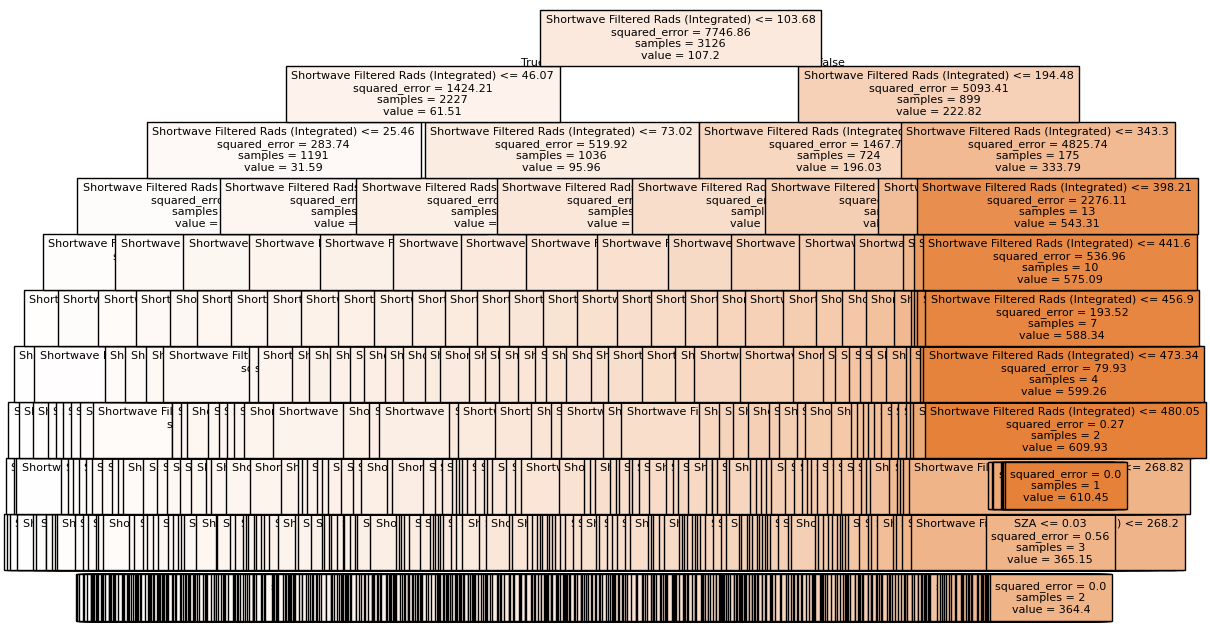

In [167]:
plt.figure(figsize=(12, 8))
plot_tree(all_unscaled_res_random_forest[0]["Model"].estimators_[0], feature_names=['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)'],
          filled=True,
          max_depth=10,
          fontsize=8,
          proportion=False,
          precision=2)

plt.savefig('tree.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# plot_ml_est(snow_est_tests)

In [15]:
# plot_ml_est(land_est_tests)

In [46]:
# clear_est_tests = estimator_testing("land", clear_dataset)
# clear_est_tests

In [16]:
# plot_ml_est(clear_est_tests)

Block diagram + Physical explanation: Start with a clear diagram showing the deterministic nature of the problem. Emphasize that you're essentially "inverting" a known filter operation using SZA/VZA/RAZ and filtered values to recover unfiltered data - this isn't a typical noisy prediction problem.

Truth vs. Prediction visualizations:

Scatter plots of predicted vs. ground truth values (should fall very close to y=x line)

Residual plots (prediction - ground truth) to show error distribution

Histogram of percentage errors (pred - truth)/truth × 100%


In [36]:
all_unscaled_y_pred_random_forest = np.squeeze(all_unscaled_res_random_forest[1])
all_unscaled_y_true_random_forest = np.squeeze(all_unscaled_res_random_forest[2])
# all_unscaled_y_true_random_forest = all_unscaled_res_random_forest[2]["Shortwave Unfiltered Rads (Integrated)"]
all_unscaled_residuals_random_forest = all_unscaled_y_pred_random_forest - all_unscaled_y_true_random_forest

np.shape(all_unscaled_y_pred_random_forest), np.shape(all_unscaled_y_true_random_forest), np.shape(all_unscaled_residuals_random_forest)

((1239,), (1239,), (1239,))

In [37]:
all_unscaled_y_pred_linear_regression = np.squeeze(all_unscaled_res_linear_regression[1])
all_unscaled_y_true_linear_regression = np.squeeze(all_unscaled_res_linear_regression[2])
all_unscaled_residuals_linear_regression = all_unscaled_y_pred_linear_regression - all_unscaled_y_true_linear_regression

np.shape(all_unscaled_y_pred_linear_regression), np.shape(all_unscaled_y_true_linear_regression), np.shape(all_unscaled_residuals_linear_regression)

((1239,), (1239,), (1239,))

In [38]:
all_unscaled_y_pred_mlp = np.squeeze(all_unscaled_mlp[1])
all_unscaled_y_true_mlp = np.squeeze(all_unscaled_mlp[2])
all_unscaled_residuals_mlp = all_unscaled_y_pred_mlp - all_unscaled_y_true_mlp

np.shape(all_unscaled_y_pred_mlp), np.shape(all_unscaled_y_true_mlp), np.shape(all_unscaled_residuals_mlp)

((1239,), (1239,), (1239,))

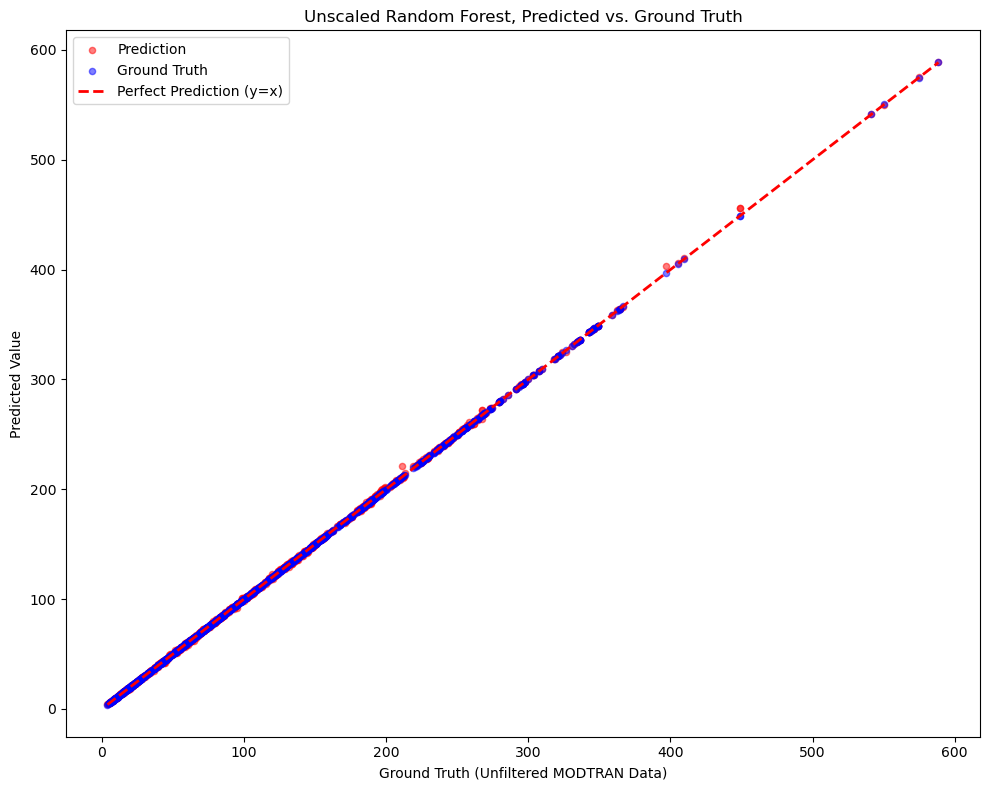

In [42]:
## Ground truth v predictions
fig, ax = plt.subplots(figsize=(10, 8))
# scatter = ax.scatter(all_unscaled_y_true_random_forest, all_unscaled_y_pred_random_forest, alpha=0.5, s=20)

# Plot predictions as orange crosses
ax.scatter(all_unscaled_y_true_random_forest, all_unscaled_y_pred_random_forest,
           alpha=0.5, s=20, color='red', label='Prediction')

ax.scatter(all_unscaled_y_true_random_forest, all_unscaled_y_true_random_forest,
           alpha=0.5, s=20, color='blue', label='Ground Truth')
# Add perfect prediction line (y=x)
line_x = np.linspace(all_unscaled_y_true_random_forest.min(), all_unscaled_y_true_random_forest.max(), 100)
line_y = line_x
ax.plot(line_x, line_y, 'r--', linewidth=2, label='Perfect Prediction (y=x)')
ax.set_xlabel('Ground Truth (Unfiltered MODTRAN Data)')
ax.set_ylabel('Predicted Value')
ax.set_title(f'Unscaled Random Forest, Predicted vs. Ground Truth')
ax.legend()
fig.tight_layout()

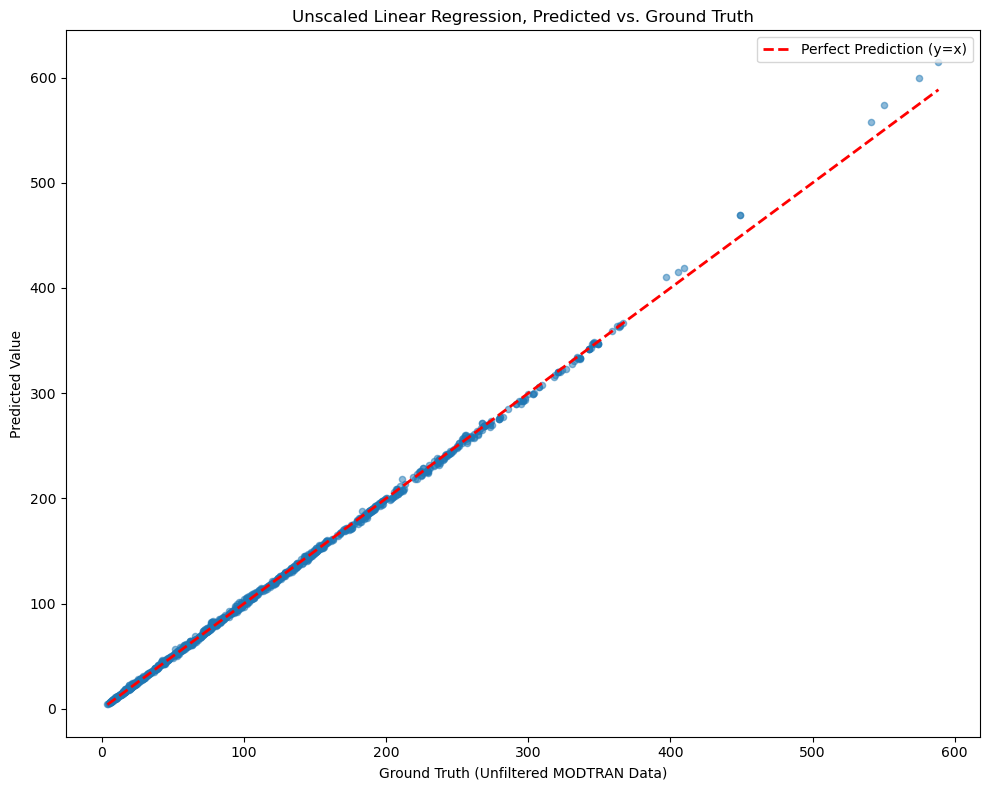

In [180]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(all_unscaled_y_true_linear_regression, all_unscaled_y_pred_linear_regression, alpha=0.5, s=20)
# Add perfect prediction line (y=x)
line_x = np.linspace(all_unscaled_y_true_linear_regression.min(), all_unscaled_y_true_linear_regression.max(), 100)
line_y = line_x
ax.plot(line_x, line_y, 'r--', linewidth=2, label='Perfect Prediction (y=x)')
ax.set_xlabel('Ground Truth (Unfiltered MODTRAN Data)')
ax.set_ylabel('Predicted Value')
ax.set_title(f'Unscaled Linear Regression, Predicted vs. Ground Truth')
ax.legend()
fig.tight_layout()

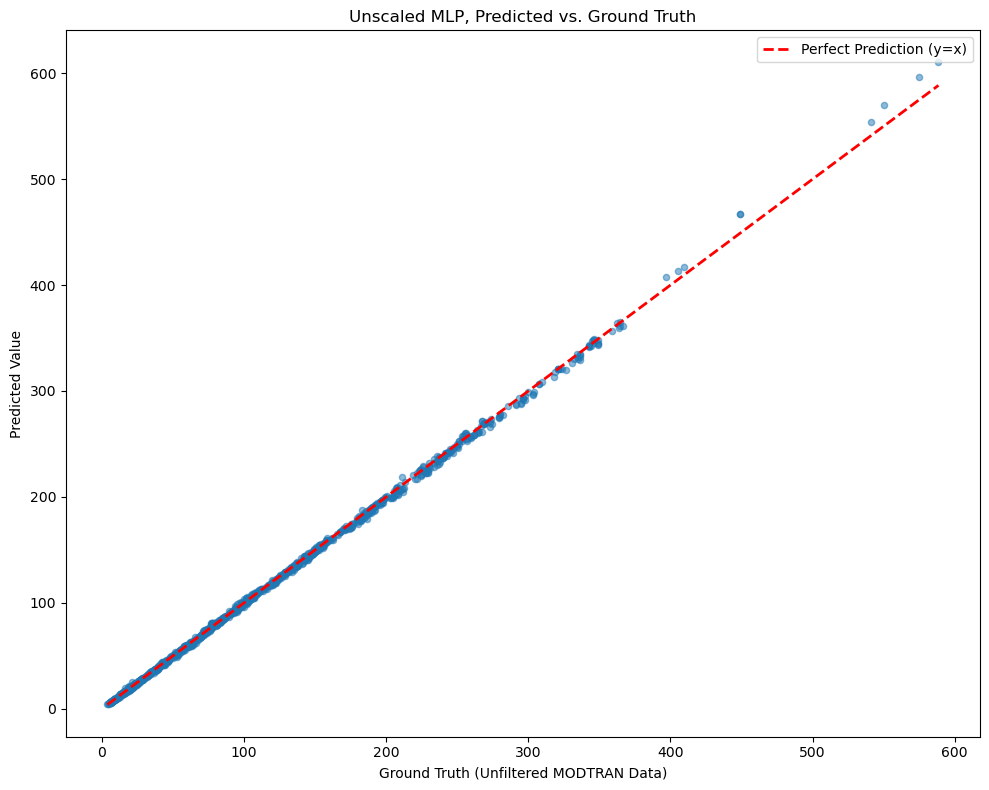

In [181]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(all_unscaled_y_true_mlp, all_unscaled_y_pred_mlp, alpha=0.5, s=20)
# Add perfect prediction line (y=x)
line_x = np.linspace(all_unscaled_y_true_mlp.min(), all_unscaled_y_true_mlp.max(), 100)
line_y = line_x
ax.plot(line_x, line_y, 'r--', linewidth=2, label='Perfect Prediction (y=x)')
ax.set_xlabel('Ground Truth (Unfiltered MODTRAN Data)')
ax.set_ylabel('Predicted Value')
ax.set_title(f'Unscaled MLP, Predicted vs. Ground Truth')
ax.legend()
fig.tight_layout()

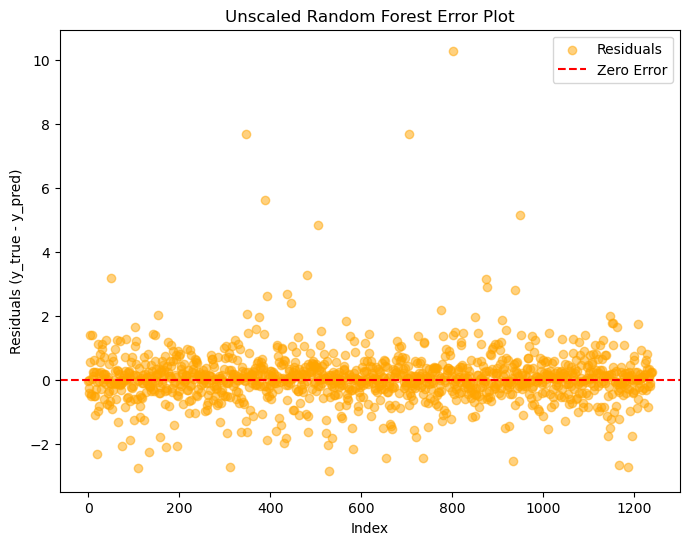

In [182]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(all_unscaled_residuals_random_forest)), all_unscaled_residuals_random_forest, alpha=0.5, color='orange', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Index')
plt.ylabel('Residuals (y_true - y_pred)')
plt.title('Unscaled Random Forest Error Plot')
plt.legend()
plt.show()

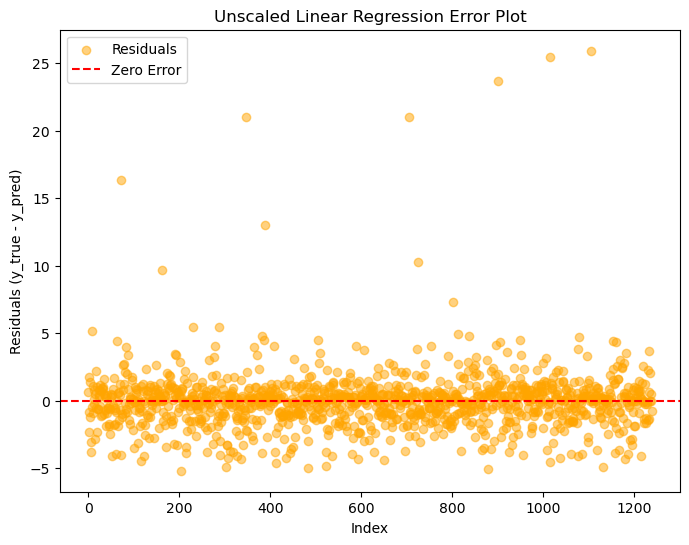

In [183]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(all_unscaled_residuals_linear_regression)), all_unscaled_residuals_linear_regression, alpha=0.5, color='orange', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Index')
plt.ylabel('Residuals (y_true - y_pred)')
plt.title('Unscaled Linear Regression Error Plot')
plt.legend()
plt.show()

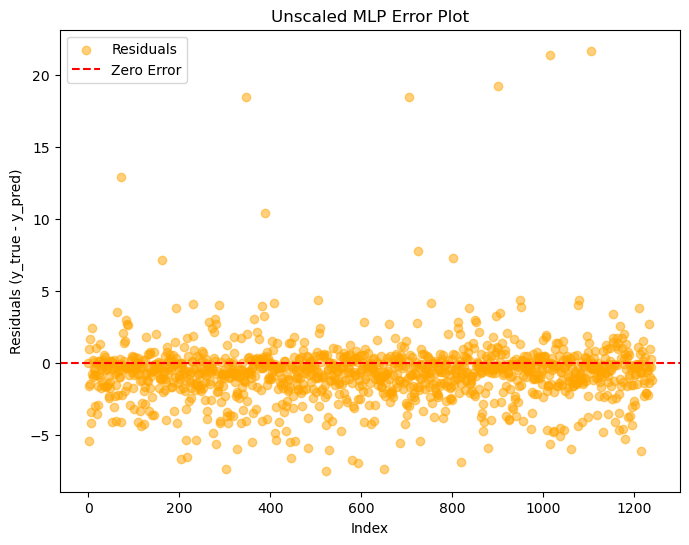

In [184]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(all_unscaled_residuals_mlp)), all_unscaled_residuals_mlp, alpha=0.5, color='orange', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Index')
plt.ylabel('Residuals (y_true - y_pred)')
plt.title('Unscaled MLP Error Plot')
plt.legend()
plt.show()

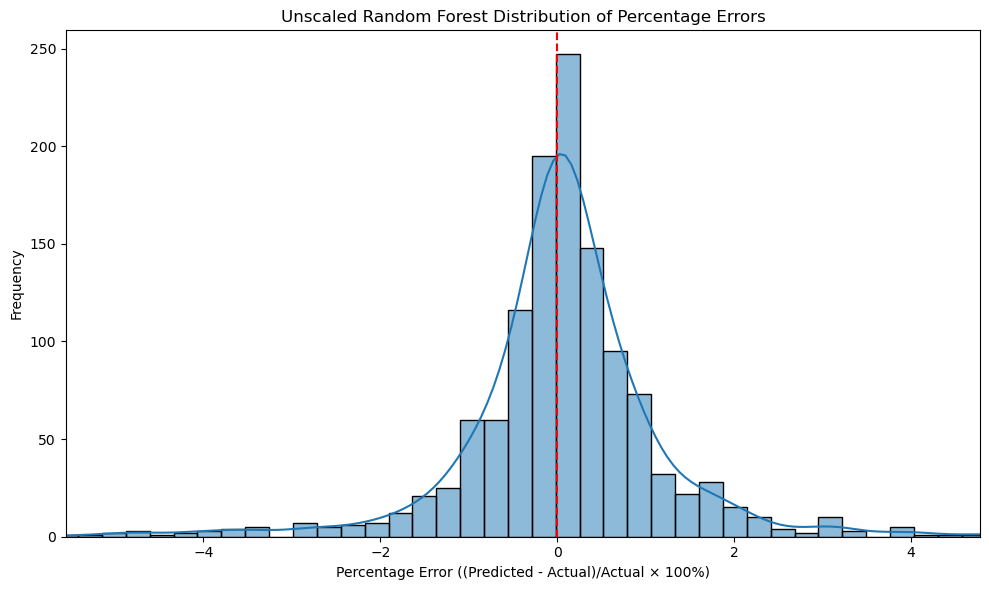

In [185]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_random_forest - all_unscaled_y_true_random_forest) / all_unscaled_y_true_random_forest
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Random Forest Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

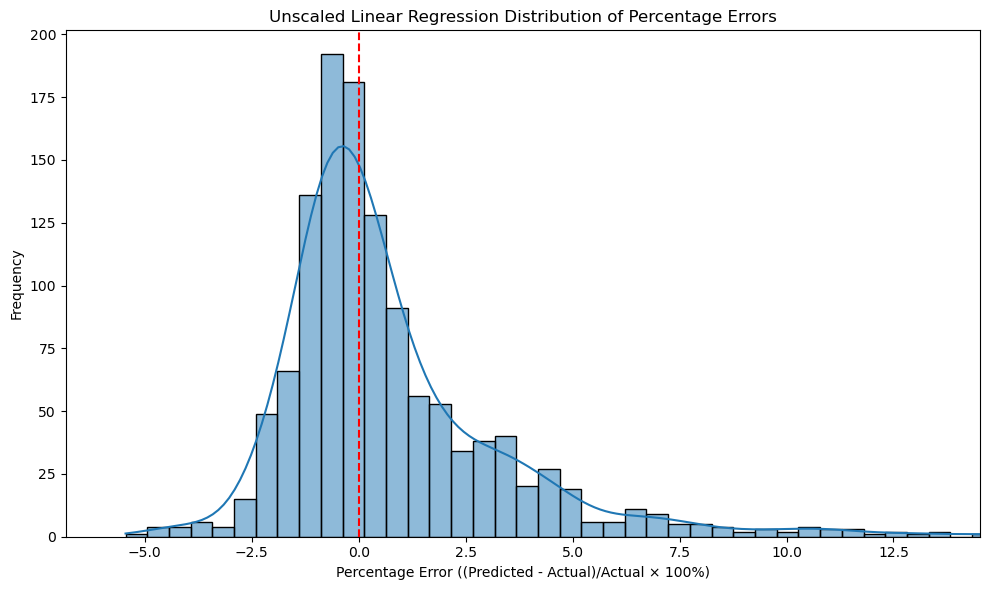

In [186]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_linear_regression - all_unscaled_y_true_linear_regression) / all_unscaled_y_true_linear_regression
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Linear Regression Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

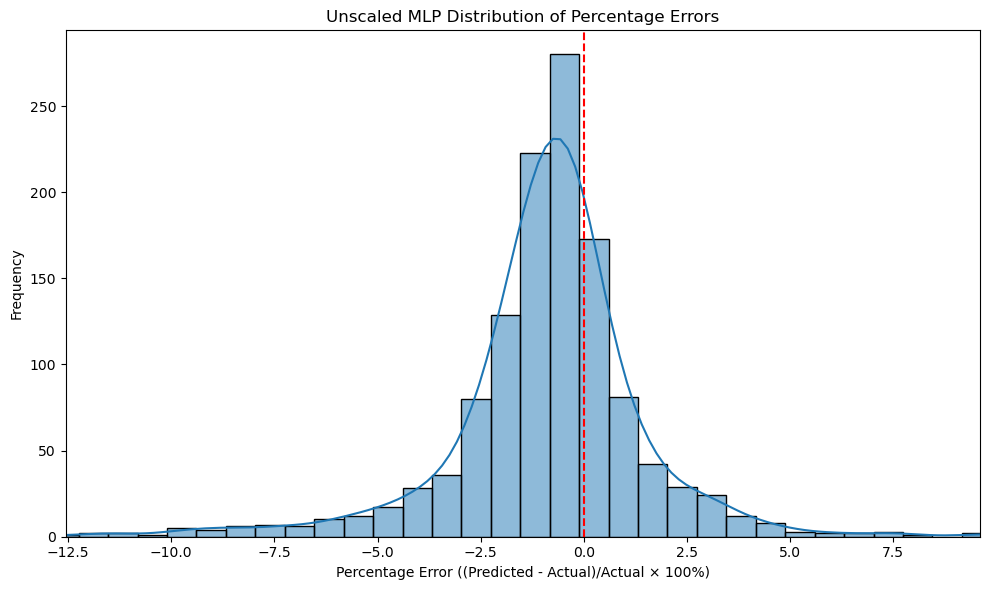

In [187]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_mlp - all_unscaled_y_true_mlp) / all_unscaled_y_true_mlp
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled MLP Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

Performance breakdown by conditions:

Stratify errors by SZA ranges to show consistency across different angles

Create separate plots for different scenes to demonstrate robustness

Show error metrics for different atmospheric conditions if applicable

Model validation experiments, MLP vs Tree:

Plot R² and RMSE vs. number of estimators (should plateau quickly if truly deterministic)

Show cross-validation results across different data splits

Plot learning curves to show how quickly the model reaches high accuracy


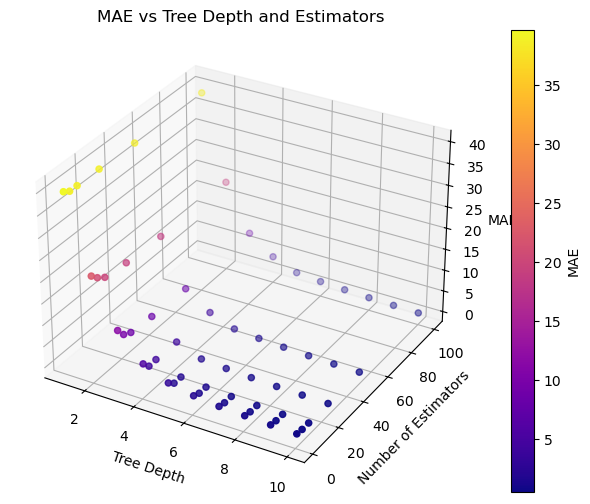

In [43]:
tree_est = []
tree_depths = []
maes = np.array([])
for key, value in all_td_est_comparison.items():
    tree_depths.append(key[0])
    tree_est.append(key[1])
    maes = np.append(maes, value[0]["Mean_Absolute_Error"])

half = len(tree_est) // 2
tree_df = pd.DataFrame({
    "Tree_Est": tree_est[:half],
    "Tree_Depth": tree_depths[:half],
    "mae": maes[:half]
})

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter
sc = ax.scatter(tree_depths, tree_est, maes, c=maes, cmap='plasma')
ax.set_xlabel("Tree Depth")
ax.set_ylabel("Number of Estimators")
ax.set_zlabel("MAE")
plt.title("MAE vs Tree Depth and Estimators")

# Color bar
fig.colorbar(sc, label="MAE")
plt.show()

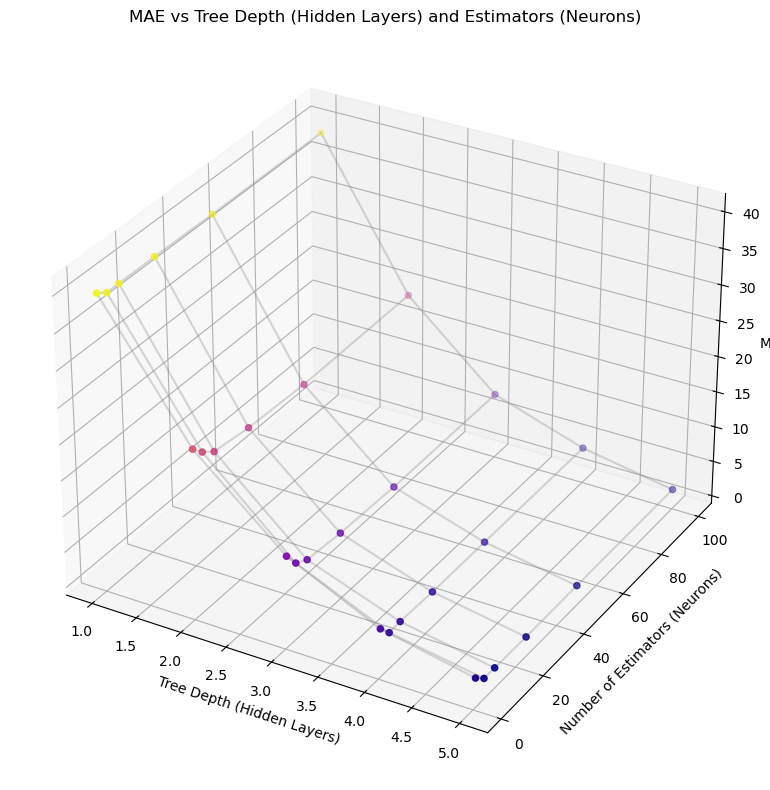

In [51]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter
sc = ax.scatter(tree_df['Tree_Depth'], tree_df['Tree_Est'], tree_df['mae'], c=tree_df['mae'], cmap='plasma')

# # Group by depth and plot lines between estimators
# for depth in tree_df['Tree_Depth'].unique():
#     subset = tree_df[tree_df['Tree_Depth'] == depth].sort_values(by='Tree_Est')
#     ax.plot(subset['Tree_Depth'], subset['Tree_Est'], subset['mae'], color='gray', alpha=0.5)
for depth in tree_df['Tree_Depth'].unique():
    subset = tree_df[tree_df['Tree_Depth'] == depth].sort_values(by='Tree_Est')
    ax.plot(subset['Tree_Depth'], subset['Tree_Est'], subset['mae'], color='gray', alpha=0.3)



for est in tree_df['Tree_Est'].unique():
    subset = tree_df[tree_df['Tree_Est'] == est].sort_values(by='Tree_Depth')
    ax.plot(subset['Tree_Depth'], subset['Tree_Est'], subset['mae'], color='gray', alpha=0.3)

ax.set_xlabel("Tree Depth (Hidden Layers)")
ax.set_ylabel("Number of Estimators (Neurons)")
ax.set_zlabel("MAE")
# ax.set_zlabel("MAE", labelpad=10)
plt.title("MAE vs Tree Depth (Hidden Layers) and Estimators (Neurons)")
# fig.colorbar(sc, label="MAE")
fig.tight_layout()

plt.show()

[1, 5, 10, 25, 50, 100, 1, 5, 10, 25, 50, 100, 1, 5, 10, 25, 50, 100, 1, 5, 10, 25, 50, 100, 1, 5, 10, 25, 50, 100]


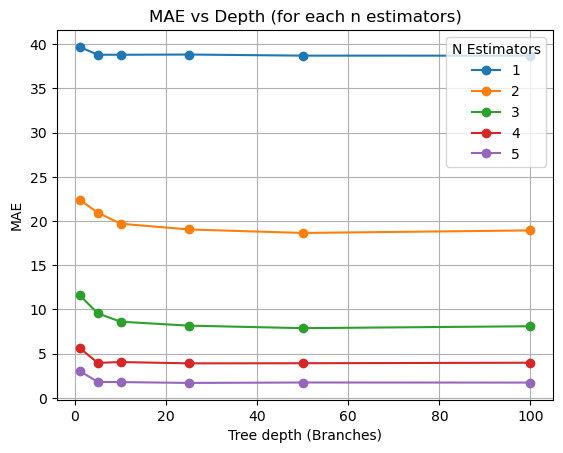

In [190]:

print(tree_est[:half])

# Pivot for plotting: rows = layer, cols = iter, values = mae
pivot = tree_df.pivot_table(index='Tree_Est', columns='Tree_Depth', values='mae')

pivot.plot(marker='o')
plt.xlabel("Tree depth (Branches)")
plt.ylabel("MAE")
plt.title("MAE vs Depth (for each n estimators)")
plt.legend(title="N Estimators")
plt.grid(True)
plt.show()

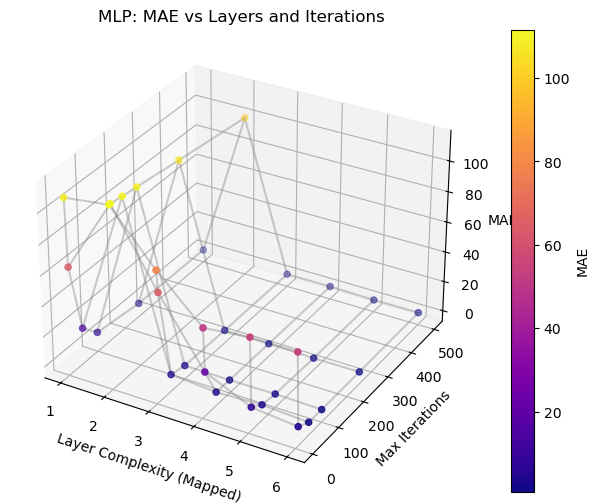

In [191]:
layer_map = {
    '2': 1,
    '(2, 2)': 2,
    '(4, 2)': 3,
    '(8, 4)': 4,
    '(16, 8)': 5,
    '(32, 16, 8)':6
}

mlp_iter = []
mlp_layers = []
mlp_maes = np.array([])
for key, value in all_mlp_neurons_iters_comparison.items():
    mlp_layers.append(str(key[0]))
    mlp_iter.append(key[1])
    mlp_maes = np.append(mlp_maes, value[0]["Mean_Absolute_Error"])
    
mlp_layer_nums = [layer_map[l] for l in mlp_layers]

mlp_df = pd.DataFrame({
    "layer": mlp_layer_nums,
    "iter": mlp_iter,
    "mae": mlp_maes
})

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Connect points with the same layer (varying iter)
for layer in mlp_df['layer'].unique():
    subset = mlp_df[mlp_df['layer'] == layer].sort_values('iter')
    ax.plot(subset['layer'], subset['iter'], subset['mae'], color='gray', alpha=0.4)

# Connect points with the same max_iter (varying layer complexity)
for it in mlp_df['iter'].unique():
    subset = mlp_df[mlp_df['iter'] == it].sort_values('layer')
    ax.plot(subset['layer'], subset['iter'], subset['mae'], color='gray', alpha=0.4)


sc = ax.scatter(mlp_layer_nums, mlp_iter, mlp_maes, c=mlp_maes, cmap='plasma')
ax.set_xlabel("Layer Complexity (Mapped)")
ax.set_ylabel("Max Iterations")
ax.set_zlabel("MAE")
plt.title("MLP: MAE vs Layers and Iterations")
fig.colorbar(sc, label="MAE")
plt.show()

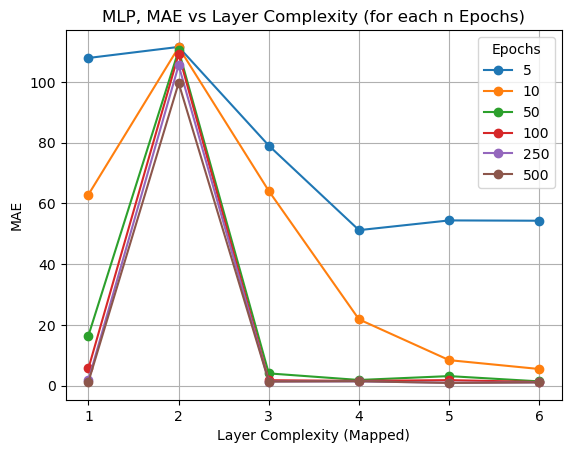

In [192]:
# Pivot for plotting: rows = layer, cols = iter, values = mae
pivot = mlp_df.pivot_table(index='layer', columns='iter', values='mae')

pivot.plot(marker='o')
plt.xlabel("Layer Complexity (Mapped)")
plt.ylabel("MAE")
plt.title("MLP, MAE vs Layer Complexity (for each n Epochs)")
plt.legend(title="Epochs")
plt.grid(True)
plt.show()

Synthetic tests to prove concept:

Add controlled noise to your inputs and show how accuracy degrades predictably

Create a simplified version of the problem where you apply a known filter to data, then show the model can recover it almost perfectly


In [102]:
all_mlp_noise_comparison

{0: [{'Mean_Absolute_Error': 1.4142247221960287,
   'Train_Accuracy': 0.9993642017730769,
   'Test_Accuracy': 0.9993469587453174,
   'Mean_Squared_Error': 5.386730395048138,
   'R_Squared': 0.9993469587453174,
   'Cross_Validated_Root_Mean_Squared_Error': array([2.9224335 , 3.28397799, 0.74450014, 3.26972216, 2.01928419]),
   'Cross_Validated_R_Squared': array([0.99867804, 0.99887173, 0.9998066 , 0.99859374, 0.99921211]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=(8, 4), learning_rate='adaptive',
                max_iter=500, random_state=42)},
  array([ 50.28241833,  87.826602  , 343.35429608, ...,  21.17514442,
          16.47522386, 126.40504149]),
        Shortwave Unfiltered Rads (Integrated)
  2941                               50.313969
  2366                               86.838952
  1634                              348.782641
  5035                               62.199197
  1212                               96.241008
  ...                                      

In [103]:
all_tree_noise_comparison

{0: [{'Mean_Absolute_Percentage_Error': 0.7347429658625121,
   'Root_Mean_Squared_Error': 0.8544535030709338,
   'Mean_Absolute_Error': 0.5072555753714032,
   'Accuracy': 99.26525703413749,
   'Cross_Validated_Root_Mean_Squared_Error': array([5.77987368, 2.15911602, 0.93868794, 1.78663513, 3.0470108 ]),
   'Cross_Validated_R_Squared': array([0.99482909, 0.99951229, 0.99969256, 0.99958013, 0.99820601]),
   'R_Squared': 0.9999114900190178,
   'Model': RandomForestRegressor(max_depth=10, random_state=42)},
  array([ 50.2935176 ,  86.5743519 , 348.77291356, ...,  21.16437618,
          16.99820388, 127.8343468 ]),
        Shortwave Unfiltered Rads (Integrated)
  2941                               50.313969
  2366                               86.838952
  1634                              348.782641
  5035                               62.199197
  1212                               96.241008
  ...                                      ...
  5613                               32.616666
  5072

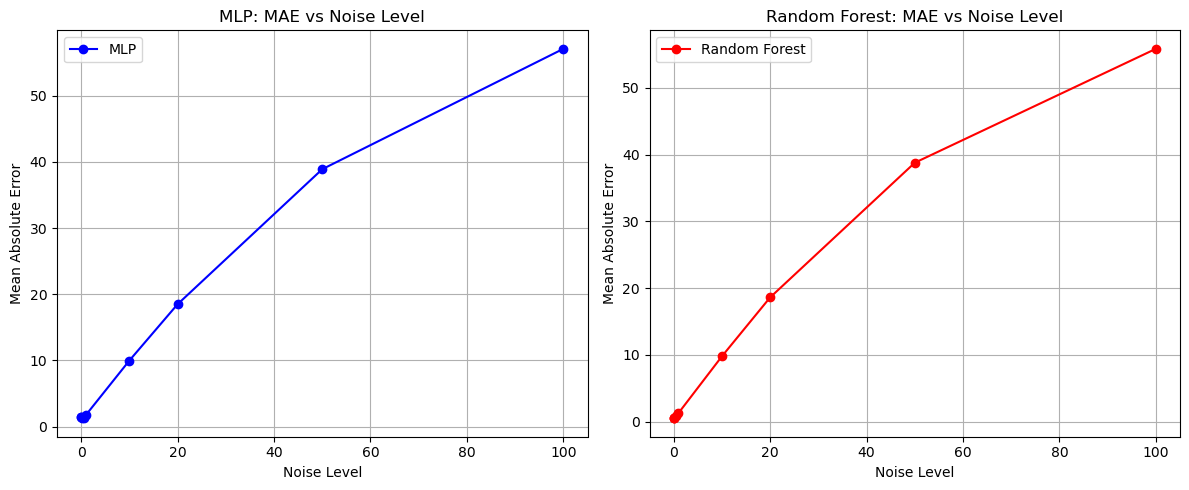

In [193]:
# Create noise comparison plots for MLP and Random Forest
plt.figure(figsize=(12, 5))

# MLP noise comparison
plt.subplot(1, 2, 1)
noise_levels = list(all_mlp_noise_comparison.keys())
mlp_maes = [results[0]['Mean_Absolute_Error'] for results in all_mlp_noise_comparison.values()]
plt.plot(noise_levels, mlp_maes, 'b-o', label='MLP')
plt.xlabel('Noise Level')
plt.ylabel('Mean Absolute Error')
plt.title('MLP: MAE vs Noise Level')
plt.grid(True)
plt.legend()

# Random Forest noise comparison  
plt.subplot(1, 2, 2)
noise_levels = list(all_tree_noise_comparison.keys())
rf_maes = [results[0]['Mean_Absolute_Error'] for results in all_tree_noise_comparison.values()]
plt.plot(noise_levels, rf_maes, 'r-o', label='Random Forest')
plt.xlabel('Noise Level')
plt.ylabel('Mean Absolute Error')
plt.title('Random Forest: MAE vs Noise Level')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


Physical validation:

Plot specific spectral features that would be physically interpretable to an atmospheric scientist

Compare your model's predictions with physics-based models for specific test cases

Demonstrate how the predicted unfiltered data maintains expected physical relationships



Since your PI has an atmospheric research background, frame this in terms they'll understand - your model is essentially learning the inverse radiative transfer function between filtered and unfiltered data, conditioned on viewing geometry. The high accuracy reflects the deterministic physical relationship between these variables, not an error in methodology